# Spatial Data Models

Geospatial data represents real-world features on Earth's surface. Before working with geospatial data in Python, it is essential to understand how geographic features are represented digitally. This module introduces the two fundamental data models used in GIS: **vector** and **raster**.

**Topics covered in this module:**
- Overview of the vector and raster data models
- Geometry types: Point, LineString, Polygon, and Multi-geometries
- Common geospatial file formats (Shapefile, GeoJSON, GeoPackage, GeoTIFF, NetCDF)
- Hands-on practice creating vector geometries with Python's `shapely` library

## Learning Objectives

At the end of this module, you should be able to:
- Describe the difference between vector and raster data models and identify when each is appropriate
- List common geospatial file formats (Shapefile, GeoJSON, GeoPackage, GeoTIFF, NetCDF) and their key characteristics
- Create Point, LineString, and Polygon geometry objects using Python's `shapely` library
- Access geometry properties such as coordinates, length, area, bounds, and centroid
- Calculate distances between geometric objects using shapely

## Data Models

- How can we represent geographic features such as roads, buildings, lakes or mountains on a computer? 
- How can we read an image taken with a satellite sensor and use that in our analyses? 
- How can we create a spatial network that can be used for navigation and finding the fastest route from A to B? 

This module introduces you to the fundamental data structures and formats that are most commonly used when working with Geographic Information Systems (GIS) and spatial data analysis.

To be able to work with real world geographic objects on a computer, we need to represent them in a format that the computer can understand and work with. These representations are simplifications of the real world.

- **vector** data model
- **raster** data model

Vector and raster data formats are very different by nature. Figure 1 shows how physical objects, such as roads and buildings, can be represented as vectors or rasters. In addition, there are other models such as **spatio-temporal data model** which incorporates time as one additional dimension to the geographic dimension. There are also models that *integrate* vector or raster data models, such as **topological data model** which is typically build around vector data. This model can be used to represent e.g. street **networks** in a way that the topological relationships are incorporated in the core model design.

The vector representation of road and building features (shown on the left in Figure 1) are constructed from points in geographical space which are connected to each other forming lines and polygons. The subplots on the right, shows raster representations of the same features. They are constructed from rectangular cells (also called **pixels**) that form a uniform grid, i.e. a raster. The grid is associated to specific geographical location and each cell of the grid contains a value representing some information, such as elevation, temperature, or presence/absence (as in this figure). 

Lastly, the roads on the top-left could be represented as a network, which is a vector-based data structure consisting of intersections (called **nodes**) that are represented as points, and streets connecting the nodes that are represented as lines (called *edges*). Because the vector and raster data models are very different, there are a different set of GIS tools and methodologies applied for raster and vector data. However, the vector and raster worlds are not totally isolated from each other, as in many cases it is useful to convert the data from one format to another for specific operations.

<img src="img/vector_vs_raster.png" width="800">

_**Figure 1.** Vector and raster representations of roads and buildings._

## Basics of vector data

### Geometry types

The most fundamental geometric objects in vector format are `points`, `lines`, and `polygons`.

Figure 2 represents the vector data model and illustrates the variety of geometric objects. 

- `Point` object represents a single point in geographic space and the location of the point in space is determined with coordinates. Points can be either two-dimensional (with x, y -coordinates) or three dimensional (with x, y, and z coordinates). A single pair of coordinates forming a point is called a `coordinate tuple`.

- `LineString` object (i.e. a line) represents a sequence of points joined together to form a line. Hence, a line consists of a list of at least two coordinate tuples. 

- `Polygon` object represents a filled area that consists of a list of at least three coordinate tuples that forms the exterior ring (called `LinearRing`) and a possible list of holes (as seen in the last plot of Figure 2).

### Collection of geometric objects.

All of the fundamental geometric types can be combined to represent more complex geographic features, such as administrative areas that consist of multiple discontinuous regions. It is also possible to have a collection of geometric objects (i.e. multiple points, lines or areas) represented as `MultiPoint`, `MultiLineString` and `MultiPolygon` as shown in the bottom row of Figure 2. Geometry collections can be useful, e.g., when you want to present multiple building polygons belonging to the same property as a single entity.

- **MultiPoint** geometries represent collections of points.
- **MultiLineString** geometries represent collections of lines.
- **MultiPolygon** geometries represent collections of polygons.
- **GeometryCollection** geometries are collections of points, lines, and polygons, as well as multi-points, multi-lines, and multi-polygons.

All of these geometries are defined in the **Simple Features Access Specification**, which is a standard (ISO 19125-1) formalized by the *Open Geospatial Consortium* and *International Organization for Standardization*. Most programming languages follow this same standard to represent spatial data. The text underneath each geometry (e.g. Point (25 60.5)) shows how each of these geometries can be represented as text (Figure 2). The way the text is formatted follows a specification called *`Well-known text` (WKT)* which is also defined in the Simple Features Access Specification. 

The geometries can also be represented in binary format, which is called  *`Well-known binary` (WKB)*. WKB is useful for storing geometries in a more compact form, but it is not human-readable. Most often, you don't need to worry about these technical details when working with spatial data in Python, but it is useful to know the foundations underlying most GIS libraries.

<img src="img/vector_data_model.png" width="800">

_**Figure 2.** Vector data model following the Simple Features Access Specification._

### Attribute data

The geometry of a feature is one aspect of geospatial data which tells us about the location and possibly the shape of the real-world entity at hand. However, the other aspect which is equally important is the information that we associate with the geometry as an attribute data. Attribute data is typically attached to the geometries that describe the given entity with various possible characteristics. 

For example, in terms of a building geometry, we might have useful attribute information, such as the number of floors, the height of the building, or how many people live there. Attributes are always linked to the geometries in one way or another, e.g., based on a unique feature identifier which is referenced both in the attribute table and the geometry records (e.g. when working with `Shapefiles`). The linking can also be done on a structural level of the data, such as in `GeoJSON` format in which a single feature always contains both the geometry and attribute information.

### Vector data formats

Vector data can be stored in different ways. Two widely used approaches are to either store the data into a spatial data file on disk, or store the data into a spatially-aware database, such as PostGIS database. When storing data to a data file there are multiple options of data formats. You can read and write spatial vector data to approximately eighty different file formats which are supported by the [Geospatial Data Abstraction Library](https://gdal.org/) (GDAL).

`GDAL` is a computer software library for reading and writing raster and vector geospatial data formats, and it is used under the hood by hundreds of GIS software and libraries in different programming languages (including Python). Below, we will provide information about a few vector data formats.

- **Shapefile:** Shapefile (`.shp`) is a widely used data format for storing geospatial vector data, which was developed and introduced by ESRI in the early 1990s. Shapefile is actually not a single file, but is made of multiple separate files. The three mandatory files associated with a valid shapefile dataset are:
    - `.shp` containing the feature geometries, 
    - `.shx` containing a positional index for the feature geometries, and 
    - `.dbf` containing the attribute information. 
    - In addition, a shapefile typically includes a `.prj` file with information about the coordinate reference system. 

- **GeoJSON**: GeoJSON (`.geojson`) is an open standard format for encoding a variety of geographic data structures along with their attribute data which can be stored into a simple text file. The data format extends the widely used JSON format. GeoJSON is human readable and the data is not compressed, hence the files can become large when storing complex geometries. Because of this, another variation of GeoJSON was developed called `TopoJSON` which is a more compact format. TopoJSON stores the geometries in a way that they can be referenced multiple times in the file, e.g. when two polygons share a common border between them. 

  - An example of GeoJSON data structure:

    ```
    {"type": "FeatureCollection",
      "features": [
        {"type": "Feature", "properties": {"id": 75553155, "timestamp": 1494181812},
          "geometry": {"type": "MultiLineString",
            "coordinates": [[[26.938, 60.520], [26.938, 60.520]], [[26.937, 60.521],
                             [26.937, 60.521]], [[26.937, 60.521], [26.936, 60.522]]]
          }
        }, 
        {"type": "Feature", "properties": {"id": 424099695, "timestamp": 1465572910}, 
          "geometry": {"type": "Polygon",
            "coordinates": [[[26.935, 60.521], [26.935, 60.521], [26.935, 60.521],
                             [26.935, 60.521], [26.935, 60.521]]]
          }
        }
      ]
    }
    
    ```

- **GeoPackage:** A GeoPackage (`.gpkg`) is an open, non-proprietary, platform-independent, portable, and standards-based data format for storing spatial data. In the background, GeoPackage uses a SQLite database container to store the data. GeoPackage was introduced in 2014 by Open Geospatial Consortium and it can be used to store vector data as well as raster data. However, the GeoPackage raster support is limited as it supports only `Byte` data type.

- **GML**: [Geography Markup Language](https://www.ogc.org/standards/gml) (`.gml`) is an XML-based data format defined by the Open Geospatial Consortium (OGC) to express geographical features. GML serves as a modeling language for geographic systems as well as an open interchange format for geographic transactions on the Internet. Key to GML's utility is its ability to integrate all forms of geographic information, including not only conventional "vector" or discrete objects, but also coverages and sensor data. There are various extensions to GML, such as [CityGML](https://www.ogc.org/standards/citygml) focusing on 3D city models and [IndoorGML](https://www.ogc.org/standards/citygml) focusing on indoor spatial information.

- **GeoParquet**: [GeoParquet](https://github.com/opengeospatial/geoparquet) (`.parquet`) is not a new file format itself, but rather a set of conventions for storing geospatial data within the existing Apache Parquet columnar storage format. By using the standard `.parquet` extension, GeoParquet files maintain maximum compatibility and interoperability with existing Parquet tools and big data processing frameworks like Apache Spark and Dask, while the necessary geospatial metadata is embedded within the file's schema. It provides efficient data compression and encoding schemes with enhanced performance to handle complex data in bulk.

- **KML**: [Keyhole Markup Language](https://developers.google.com/kml/documentation/kml_tut) (`.kml`) is an XML-based format for geographic data, used to display points, lines, polygons, and images on maps and 3D globes, like in Google Earth or ArcGIS. A related .kmz file is a compressed version, bundling the .kml with its images and other assets into a single file for easier sharing.

## Basics of raster data

In raster data model, data is represented as arrays of cells or pixels, to represent real-world objects or continuous phenomena. You are likely already familiar with raster data as photographs taken with a digital camera are basically stored as raster data. Digital cameras typically capture the world using Red, Green and Blue (RGB) colors and stores this information in pixels as separate layers (also called `bands` or `channels`) for each color. When these layers of red, green and blue colors are combined, we get a photograph as we have used to see them. 

In a similar manner, we can store other information to pixels, such as elevation or temperature (which have only one layer or `band`), or more detailed spectral information that capture how the light reflects from objects on earth at different wavelengths or multiple bands. In these cases, we might have tens or even hundreds of different bands (as with hyperspectral imaging) that record very detailed information about how the light reflects from the earth at wavelengths from visible to thermal infrared.

Most typically the raster data produced by different sensors can vary based on their:

- `spatial resolution`, i.e. the size of a single pixel
- `temporal resolution`, i.e. how frequently the data is captured from the same area of the Earth
- `spectral resolution`, i.e. the number and location of spectral bands in the electromagnetic spectrum
- `radiometric resolution`, i.e. the range of available brightness values (bit depth), usually measured in bits (binary digits)
- `spatial extent`, i.e. how large area of the world a single image represents
- `coordinate reference system`, i.e. in what CRS the data is represented 

Each cell in the raster dataset typically contains a value as shown on the left in Figure 3 (the cell value can also be `NoData`). This is different compared to vector data, in which the geometries can be unevenly distributed across space, although it is possible to also represent a regular grid with polygons, it is less efficient computationally. Each cell value also has an index (i.e. position) that can be accessed based on row and column numbers. For instance, the value (*11*) from the bottom-left corner cell can be accessed at index `(3,0)` in which the first number is the row number and the second is the column number. Cell values can be plotted according to a specific `colormap` (see the legend on the right) which turns the data into more understandable format, making it possible to detect patterns or trends from the data. For example in Figure 3, it is easy to detect that there is a cluster of high values on the bottom right corner. Detecting this pattern just by looking at cell values on the left is much more difficult task, especially if you would have much bigger raster than what we have here (4x4 grid). 

Also a basic feature of raster data is that the cell size of the grid can vary. For example, Figure 3 represents the data with 10 meter `spatial resolution`, i.e. the size of an individual cell is 10 by 10 meters. However, the bottom-right subplot in Figure 1 represents the buildings with 1 meter spatial resolution. This is an important aspect when working with raster data, because the spatial resolution determines how accurately the real-world entities can be represented or identified from the data. Raster data is commonly used to represent digital elevation models and other type of data, in which the data spatial extent is large with continuous measurements across the space. It is good to be aware though, that it is also possible to store discrete or categorical data to a raster, such as landuse classification data. Raster data is commonly used for environmental monitoring, meteorology, and cartography. 

<img src="img/raster_data_model.png" width="800">

_**Figure 3.** Raster data model._

One fundamental way to characterize a raster dataset is based on their `bit depth` (also called `pixel depth`) that provides information about the `radiometric resolution`* of the data. The bit depth defines the range of distinct values that the raster can store. For example, a 1-bit raster can only store 2 distinct values: 0 and 1, whereas 8-bit raster can have 256 different values that range between 0 to 255, as shown in Figure 4. 

<img src="img/raster_bit_depths.png" width="600">

_**Figure 4**. Examples of raster bit depths._

### Raster data formats

Similarly as with vector data, raster data can be stored in various different formats. Below we list a few of the most commonly used ones.

- **GeoTIFF**: GeoTIFF is a popular open, non-proprietary raster data format based on `TIFF format` originally developed at NASA in the early 90's. It is portable and platform independent. The file extension of GeoTIFF is `.tif`. 
- **COG**: A Cloud Optimized GeoTIFF (COG) is a file format based on GeoTIFF. COG files are typically hosted on HTTP file servers. The format can enable more efficient workflows with large data files by leveraging the ability of users to retrieve just the parts of the file that they need, instead of downloading the whole file every time. The file extension of COG is `.tif` (i.e. same as with GeoTIFF). 
- **NetCDF**: Network Common Data Form (NetCDF) is a portable, self-describing and scalable file format for storing array-oriented multidimensional scientific data, commonly used for storing earth science data. Variables stored in NetCDF are often measured multiple times per day over large (e.g. continental) areas. The file extension of NetCDF is `.nc4`. 
- **ASCII Grid**: The ASCII Raster File format is a simple format that can be used to transfer raster data between various applications. The file format was originally developed by ESRI and it is also known as Arc/Info ASCII grid. The file extension of ASCII Raster File is `.asc`. 
- **IMG**: The ERDAS Imagine file format (IMG) is proprietary file format that was originally created by an image processing software company called ERDAS. The file can be accompanied with an .xml file which stores metadata information about the raster layer. The file extension of Imagine file format is `.img`. 

## Using shapely to create, access, manipulate and analyse geometric objects

In this section, you will learn how geometric objects, such as `Point`, `LineString` and `Polygon`, are represented on a computer. Creating and representing vector-based geometric objects is most commonly done using the `shapely` library which is one of the fundamental libraries in Python GIS ecosystem. Thus, basic knowledge of shapely is highly useful when using higher-level tools that depend on it, such as geopandas.

Under the hood shapely uses a C++ library called `GEOS` to construct the geometries. GEOS is one of the standard libraries behind various GIS software, such as PostGIS and QGIS. Objects and methods available in shapely adhere mainly to the Open Geospatial Consortium’s Simple Features Access Specification, making them compatible with various GIS tools. Next, we will give a quick overview of how to create different kinds of geometries using shapely.

Shapely can perform many useful operations on geometries, and provides a range of attributes of geometries. For instance, you can:
- create lines and polygons from a set of points
- calculate the area, length, perimeter of geometries
- perform geometric operations on a set of geometries, for instance, merging (`union`), subtracting (`difference`), or calculating the distance between geometries.
- query the relationship between geometries, i.e., find out whether two geometries intersect, touch, cross, etc.

Now that we have an overview of both data models and their file formats, let us focus on vector data and learn to create geometric objects programmatically using Python.

### Creating Point geometries

When creating geometries with `shapely`, we first need to import the geometric object class which we want to create, such as `Point`, `LineString` or `Polygon`. Let's start by creating a simple `Point` object. First, we need to import the `Point` class which we can then use to create the point geometry. When creating the geometry, we need to pass the `x` and `y` coordinates (with a possible `z` -coordinate) into the `Point()` -class constructor, which will create the point geometry for us, as follows:

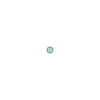

In [1]:
# import the Point class from the shapely.geometry module
from shapely.geometry import Point

point = Point(9, -3)
point

In [2]:
print(point)

POINT (9 -3)


We can also create point features in 3D coordinates:

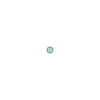

In [3]:
point3D = Point(9, -3, 6)
point3D


In the output, the letter `Z` after the `POINT` indicates that the geometry contains coordinates in three dimensions (x, y, z):

In [4]:
print(point3D)

POINT Z (9 -3 6)


As we can see, Jupyter Notebook is able to visualize the point shape on the screen. This point demonstrates a very simple geographic object that we can start using in geographic data analysis. Notice that without information about a coordinate reference system (CRS) attached to the geometry, these coordinates are ultimately just arbitrary numbers that do not represent any specific location on Earth. We will learn later how it is possible to specify a CRS for a set of geometries.

We can get the text representation of the point geometry as [Well Known Text (WKT)](https://en.wikipedia.org/wiki/Well-known_text_representation_of_geometry). `Well-Known Text` (WKT) is a standard text format for representing spatial data, like points, lines, and polygons, in a human-readable way, defined by the Open Geospatial Consortium (OGC) for use in GIS and mapping. It describes geometric shapes using simple ASCII text, making it easy to display, store, and exchange spatial data. A binary equivalent, known as `Well-Known Binary` (WKB), is used to transfer and store the same information in a more compact form convenient for computer processing but that is not human-readable.

In [5]:
point.wkt

'POINT (9 -3)'

Points and other shapely geometry objects have useful built-in [properties and methods](https://shapely.readthedocs.io/en/stable/manual.html#general-attributes-and-methods). The `geom_type` property contains information about the geometry type of a shapely geometry:

In [6]:
point.geom_type

'Point'

There are different approaches for extracting coordinates of the shapely objects. One of them is a property called `.coords`. It returns the coordinates of the point geometry as a `CoordinateSequence` which is a dedicated data structure for storing a list of coordinates. For our purposes, we can convert the `.coords` into a list that makes the values visible and make it easy to access the contents: 

In [7]:
point.coords

In [8]:
# Get coordinate tuple(s)
list(point.coords)

[(9.0, -3.0)]

However, since points, by definition, only contain one coordinate tuple,
`shapely.geometry.Point`s have properties to *directly* access its coordinate
values: the properties `x`, `y`, and (possibly) `z`, which are basic `float`
type decimal numbers.

In [9]:
# Read x and y coordinates separately
x = point.x
y = point.y

print(x, y)

9.0 -3.0


In [10]:
# Read x, y, and z
x = point3D.x
y = point3D.y
z = point3D.z

print(x, y, z)

9.0 -3.0 6.0


It is also possible to calculate the distance between two objects using the [distance](https://shapely.readthedocs.io/en/stable/manual.html#object.distance) method.

In our example the distance is calculated in a cartesian coordinate system. When working with real GIS data the distance is based on the used coordinate reference system. always check what is the **unit of measurement** (e.g., meters) in the coordinate reference system you are using.

> **Caution:** 
> Shapely geometries are, by design, agnostic (unaware) of the reference system used to represent them. Distances and surface area calculated using the built-in shapely methods will always:
> a) assume a flat, Cartesian, Euclidean space, and 
> b) return the calculated value in the unit of the coordinates (e.g., meters, or degrees).
> 
> This is perfectly fine for small-scale geospatial operations, if you **keep yourself aware of the expected output unit**. Most packages built on top of shapely, for instance [GeoPandas](https://geopandas.org/), which we will get to know in future lessons, bring their own functions and take the coordinate reference system into consideration.

In [11]:
# Check input data
point2 = Point(7,-25)
print(point)
print(point2)

# Calculate the distance between point1 and point2
dist = point.distance(point2)

# Print out a nicely formatted info message
print(f"Distance between the points is {dist:.2f} units")

POINT (9 -3)
POINT (7 -25)
Distance between the points is 22.09 units


#### Quiz
- Import the Point class from Shapely.geometry module
- Create two point objects: **p1** and **p2**, with coordinates of (0,0) and (0,3).
- Print the attributes of **p1**: wkt, coords, x, y and geom_type.
- Calculate the distance between **p1** and **p2**.

In [ ]:
# Use this cell to enter your solution.


POINT (0 0)
0.0
0.0
Point
3.0


### Creating LineString geometries

Creating a `LineString` -object is very similar to creating a `Point`-object. To create a LineString, we need at least two points that are connected to each other, which thus constitute a line. We can construct the line using either a list of Point-objects or pass the point coordinates as coordinate-tuples to the LineString constructor:

In [13]:
# import the LineString class
from shapely.geometry import Point, LineString

point1 = Point(2.2, 4.2)
point2 = Point(7.2, -25.1)
point3 = Point(9.26, -2.46)

# Create a LineString from our Point objects
line = LineString( [point1, point2, point3] )

line_from_tuples = LineString( [(2.2, 4.2), (7.2, -25.1), (9.26, -2.46)] )

# Check if the lines are identical:
line == line_from_tuples

True

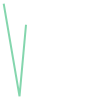

In [14]:
line

In [15]:
# Check geometry type of the line object
line.geom_type

'LineString'

In [16]:
print(line)

LINESTRING (2.2 4.2, 7.2 -25.1, 9.26 -2.46)


In [17]:
line.wkt

'LINESTRING (2.2 4.2, 7.2 -25.1, 9.26 -2.46)'

As we can see, the WKT representation of the line variable consists of multiple coordinate-pairs. In fact, the value(s) of a WKT `LINESTRING` are made up of the values of multiple WKT `POINTS`, joined together with a comma.


`LineString` ( and `LinearRing`, `MultiLineString`) objects have many useful built-in attributes and methods. It is possible to extract the coordinates, calculate its length, find its center point, create points along the line at specific interval, calculate the closest distance from a line to another geometry, or simplify the geometry. See the [shapely documentation](https://shapely.readthedocs.io/en/stable/manual.html) for full details. Most of these functionalities are directly implemented in geopandas. Hence, you rarely need to parse this information directly from the shapely geometries yourself. Here we go through a few of them for reference. 

We can extract the coordinates of a LineString similarly as with Point:

In [18]:
# Get coordinate tuples
list(line.coords)

[(2.2, 4.2), (7.2, -25.1), (9.26, -2.46)]

Because a line has to have at least two coordinate tuples, the list now contains more than the one value.


If you would need to access all x-coordinates or all y-coordinates of the line, you can use its `xy` attribute (an iterator, but we can use them as lists):

> **Warning: 3D-LineStrings**  
> Note that the `xy` property of shapely geometries does not return `z` values for three-dimensional geometries.


In [19]:
# Obtain x and y coordinates
xcoords = list(line.xy[0])
ycoords = list(line.xy[1])

print(xcoords)
print(ycoords)

[2.2, 7.2, 9.26]
[4.2, -25.1, -2.46]


Other properties of lines that are useful for GIS analyses include the length and the centre point (centroid) of lines:

In [20]:
length = line.length
centroid = line.centroid

print(f"Length of our line: {length:.2f} units")
print(f"Centroid: {centroid}")

Length of our line: 52.46 units
Centroid: POINT (6.229809472786882 -11.893134715121903)


As you can see, the centroid of the line is a `shapely.geometry.Point` object. This means that you have access to all the methods that come with the shapely Point object.

#### Quiz
- Import the LineString class from Shapely.geometry module
- Create a line object **l12** from the two points generated above (**p1** and **p2**).
- Print the attributes of **l12**: wkt, xy, geom_type.
- Calculate the length and centroid properties

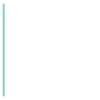

In [ ]:
# Use this cell to enter your solution.


### Creating Polygon geometries

Creating a `Polygon` object continues the same logic as creating Point and LineString objects. A Polygon can be created by passing a list of Point objects or a list of coordinate-tuples as input for the Polygon class. Polygon needs at least three coordinate-tuples to form a surface. In the following, we use the same points from the earlier LineString example to create a Polygon.

In [23]:
# import the Polygon class from the shapely.geometry module
from shapely.geometry import Polygon

# Create a Polygon from the coordinates
polygon1 = Polygon([ (2.2, 4.2), (7.2, -25.1), (9.26, -2.46)])

# Create a Polygon from a list of Point objects
polygon2 = Polygon( [point1, point2, point3] )

… or from a [`LinearRing`](https://shapely.readthedocs.io/en/stable/manual.html#linearrings)
(which has an [almost identical behaviour](#linestrings) as a `LineString`,
except that it is closed, i.e., the first and last point are identical):

In [24]:
from shapely.geometry import LinearRing

shell = LinearRing([point1, point2, point3, point1])
polygon3 = Polygon(shell)

When constructing a `shapely.geometry.LinearRing`, you can omit listing the first point again at the end; shapely will then implicitly add the first point to the end of the list of points.

In the above, we used different methods to construct three polygons. Let’s see whether they ended up describing identical geometries:

In [25]:
polygon1 == polygon2 == polygon3

True

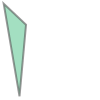

In [26]:
polygon1

In [27]:
# Geometry type
polygon1.geom_type

'Polygon'

In [28]:
print(polygon1)

POLYGON ((2.2 4.2, 7.2 -25.1, 9.26 -2.46, 2.2 4.2))


Let’s also see what its text representation is:

In [29]:
polygon1.wkt

'POLYGON ((2.2 4.2, 7.2 -25.1, 9.26 -2.46, 2.2 4.2))'

Notice that the `Polygon` WKT representation has double parentheses around the coordinates (i.e. `POLYGON ((<values in here>))` ). The current set of coordinates represents the outlines of the shape, i.e. the `exterior` of the polygon. However, a `Polygon` can also contain an optional *interior rings*, that can be used to represent holes in the polygon. You can get more information about the `Polygon` object by running `help(poly)` of from the [shapely online documentation](https://shapely.readthedocs.io/en/stable/manual.html?highlight=Polygon#Polygon):

```
class Polygon(shapely.geometry.base.BaseGeometry)
 |  Polygon(shell=None, holes=None)
 |  
 |  A two-dimensional figure bounded by a linear ring
 |  
 |  A polygon has a non-zero area. It may have one or more negative-space
 |  "holes" which are also bounded by linear rings. If any rings cross each
 |  other, the feature is invalid and operations on it may fail.
 |  
 |  Attributes
 |  ----------
 |  exterior : LinearRing
 |      The ring which bounds the positive space of the polygon.
 |  interiors : sequence
 |      A sequence of rings which bound all existing holes.
 |  
 |  Parameters
 |  ----------
 |  shell : sequence
 |     A sequence of (x, y [,z]) numeric coordinate pairs or triples.
 |     Also can be a sequence of Point objects.
 |  holes : sequence
 |      A sequence of objects which satisfy the same requirements as the
 |      shell parameters above
```


If we want to create a polygon with a hole, we can do this by using parameters `shell` for the exterior and `holes` for the interiors as follows. Notice that because a Polygon can have multiple holes, the `holes_coordinates` variable below contains nested square brackets (`[[ ]]`), which is due to the possibility of having multiple holes in a single Polygon. First, let's define the coordinates for the exterior and interior rings:

In [30]:
# Define the exterior coordinates
exterior_coordinates = [(-180, 90), (-180, -90), (180, -90), (180, 90)]

# Define the hole coordinates (a single hole in this case)
holes_coordinates = [[(-170, 80), (-170, -80), (170, -80), (170, 80)]]

The `exterior_coordinates` contains the `x` and `y` coordinates of all the corners of the polygon as a list of tuples. For instance, the first tuple `(-180, 90)` contains coordinates for the top-left corner of the polygon. Similarly, the holes_coordinates variable contains the corner coordinates of a single polygon (inside the nested list) which will represent a single hole within our Polygon. 

With the four coordinate tuples of the `exterior_coordinates`, we can first create a polygon without a hole:

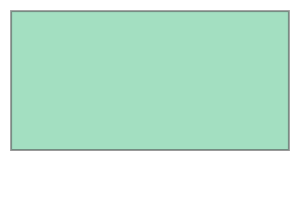

In [31]:
poly_without_hole = Polygon(shell=exterior_coordinates)
poly_without_hole

In a similar manner, we can make a `Polygon` with holes by passing the `holes_coordinates` variable into the parameter `holes`:

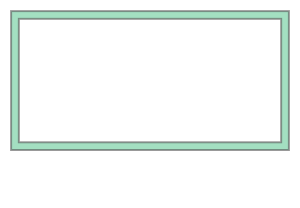

In [32]:
poly_with_hole = Polygon(shell=exterior_coordinates, holes=holes_coordinates)
poly_with_hole

As we can see, now the Polygon contains a large hole, and the actual geometry is located at the borders. Let's also take a look how the WKT representation of the polygon looks like:


In [33]:
poly_with_hole.wkt

'POLYGON ((-180 90, -180 -90, 180 -90, 180 90, -180 90), (-170 80, -170 -80, 170 -80, 170 80, -170 80))'

As we can see now the Polygon has two different tuples of coordinates. The first one represents the outer ring and the second one represents the inner ring, i.e. the hole. 

There are many useful attributes and methods related to shapely Polygon, such as `area`, `centroid`, `bounding box`, `exterior`, and `exterior-length`. For full details, see the shapely documentation. These attributes and methods are also available when working with polygon data in geopandas. Here are a couple of useful polygon attributes to remember:

In [34]:
print("Polygon centroid: ", polygon1.centroid)
print("Polygon Area: ", polygon1.area)
print("Polygon Bounding Box: ", polygon1.bounds)
print("Polygon Exterior: ", polygon1.exterior)
print("Polygon Exterior Length: ", polygon1.exterior.length)

Polygon centroid:  POINT (6.22 -7.786666666666667)
Polygon Area:  86.779
Polygon Bounding Box:  (2.2, -25.1, 9.26, 4.2)
Polygon Exterior:  LINEARRING (2.2 4.2, 7.2 -25.1, 9.26 -2.46, 2.2 4.2)
Polygon Exterior Length:  62.1627128162616


Notice, that the `length` and `area` information are presented here based on the units of the input coordinates. In our case, the coordinates actually represent longitude and latitude values. Thus, the length and area are represented as decimal degrees in this case. We can turn this information into a more sensible format (such as meters or square meters) when we start working with data in a projected coordinate system. 

Box polygons that represent the minimum bounding box of given coordinates are useful in many applications. `shapely.box` can be used for creating rectangular box polygons based on minimum and maximum `x` and `y` coordinates that represent the coordinate information of the bottom-left and top-right corners of the rectangle. Here we will use `shapely.box` to re-create the same polygon exterior.  

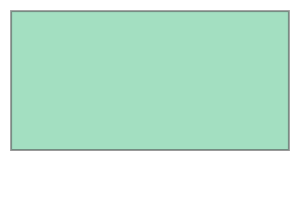

In [35]:
from shapely.geometry import box

min_x, min_y = -180, -90
max_x, max_y = 180, 90
box_poly = box(minx=min_x, miny=min_y, maxx=max_x, maxy=max_y)
box_poly

In [36]:
box_poly.wkt

'POLYGON ((180 -90, 180 90, -180 90, -180 -90, 180 -90))'

In practice, the `box` function is quite useful, for example, when you want to select geometries from a specific area of interest. In such cases, you only need to find out the coordinates of two points on the map (bottom-left and top-right corners) to be able create the bounding box polygon.   

#### Quiz

Create the following geometry objects:
- **Pentagon**, using coordinates `(30, 2.01), (31.91, 0.62), (31.18, -1.63), (28.82, -1.63), (28.09, 0.62)`
- **Triangle**, using coordinates `(1,0), (3,0), (2, 1.44)`
- **Square**, using coordinates `(0,0), (0,4), (4,4), (4,0)`
- **Square** with two holes, using exterior coordinates `(0,0), (0,4), (4,4), (4,0)` and holes coordinates `(1,1), (1,2), (2,2), (2,1)` and `(3,1), (3,2), (3.5,2), (3.5,1)`.
- **Circle** with a radius of 1 and center at (1,1), using the [buffer method of Point object](https://shapely.readthedocs.io/en/2.0.6/reference/shapely.Point.html).


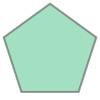

In [ ]:
# Use this cell to enter your solution.

# Pentagon



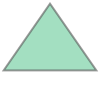

In [ ]:
# Triangle


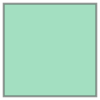

In [ ]:
# Square


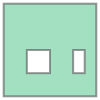

In [ ]:
# Square with two holes


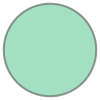

In [ ]:
# Circle



### Creating MultiPoint, MultiLineString and MultiPolygon geometries

Creating a collection of Point, LineString or Polygon objects is very straightforward now as you have seen how to create the basic geometric objects. In the Multi-versions of these geometries, you just pass a list of points, lines or polygons to the `MultiPoint`, `MultiLineString` or `MultiPolygon` constructors as shown below:

## Summary

In this module, we learned about the two fundamental geospatial data models:

- **Vector data** represents features as discrete geometries (points, lines, polygons) with associated attributes
- **Raster data** represents continuous surfaces as a grid of cells (pixels), each storing a value

We also practiced creating vector geometries in Python using `shapely`:
- `Point` for locations, `LineString` for paths, `Polygon` for areas
- Multi-geometry variants for collections of the same type
- Properties like `.area`, `.length`, `.centroid`, `.bounds`, and `.distance()`

**Key terms:**
| Term | Definition |
|------|-----------|
| **Vector** | Data model using points, lines, and polygons to represent discrete features |
| **Raster** | Data model using a grid of cells to represent continuous surfaces |
| **WKT** | Well-Known Text: a human-readable text format for representing geometries |
| **WKB** | Well-Known Binary: a compact binary format for representing geometries |
| **Shapefile** | A multi-file vector format (.shp, .dbf, .shx, .prj) widely used in GIS |
| **GeoJSON** | A JSON-based format for encoding geographic data structures |
| **GeoPackage** | A modern, single-file SQLite-based format supporting both vector and raster data |

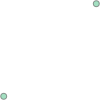

In [42]:
from shapely.geometry import MultiPoint, MultiLineString, MultiPolygon

multipoint = MultiPoint([Point(2, 2), Point(3, 3)])
multipoint

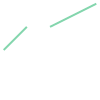

In [43]:
multiline = MultiLineString(
    [LineString([(2, 2), (3, 3)]), LineString([(4, 3), (6, 4)])]
)
multiline

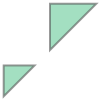

In [44]:
multipoly = MultiPolygon(
    [Polygon([(0, 0), (0, 4), (4, 4)]), Polygon([(6, 6), (6, 12), (12, 12)])]
)
multipoly